In [1]:
import numpy as np
import umap
_dataset_path = "mapelite/datasets/track_embeddings_metrics_32dim_rngMixDS_tita_circular_1.npz"
EMBEDDING_MODEL_PATH = "mapelite/embeddings/models/model_metrics_VAE/model_metrics_VAE_mixRng_tita_circular_1.pth"
_data = np.load(_dataset_path)
_embeddings = _data["embeddings"]

umap_model = umap.UMAP(n_components=2, random_state=67)
umap_model.fit(_embeddings)

d:\dev\Quality-Diversity-for-Racing-Track-Design\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,n_neighbors,15
,n_components,2
,metric,'euclidean'
,metric_kwds,None
,output_metric,'euclidean'
,output_metric_kwds,None
,n_epochs,None
,learning_rate,1.0
,init,'spectral'
,min_dist,0.1
,spread,1.0


In [ ]:
# Generate and evaluate 10 random tracks
import requests
import random

randomizer = random.Random(100)
num_tracks = 10
seed_candidates = randomizer.sample(range(1, 10000), num_tracks)

def generate_track(seed, randomizer):
    response = requests.post(
        "http://localhost:4242/generate",
        json={
            "id": seed,
            "mode": "voronoi",
            "trackSize": randomizer.randint(4, 10),
            "rngMode": 0,
        },
        timeout=60,
    )

    if not response.ok:
        raise Exception(f"API error {response.status_code}: {response.text}")

    sol = response.json()
    sol["rngMode"] = 1
    return sol

def mutate_track(sol, intensity, randomizer):
    seed = sol["id"]
    response = requests.post(
                    f"http://localhost:4242/mutate",
                    json={
                        "individual": sol,
                        "intensityMutation": intensity, # Constant mutation intensity
                        "genetic_seed": seed
                    },
                    timeout=60
                )
    if not response.ok:
                    raise Exception(f"API error {response.status_code}: {response.text}")
    mutated = response.json().get("mutated", {})
    
    # Assign a unique, iteration-based ID for tracking
    mutated["id"] = seed
    mutated["rngMode"] = sol.get("rngMode", 1) 
    
    return mutated       

def eval_track(sol):
    response = requests.post(
        "http://localhost:4242/evaluate",
        json=sol,
        timeout=60,
    )
    if not response.ok:
        raise Exception(f"API error {response.status_code}: {response.text}")

    r_json = response.json()
    return r_json.get("fitness", {})

sol = generate_track(100, randomizer)
fit = eval_track(sol)
embedding_data = fit.get("embedding_data", [])

mutated = mutate_track(sol, intensity=1000, randomizer=randomizer)
mutated_fit = eval_track(mutated)
mutated_embedding_data = mutated_fit.get("embedding_data", [])

mutated_2 = mutate_track(sol, intensity=0, randomizer=randomizer)
mutated_fit_2 = eval_track(mutated_2)
mutated_embedding_data_2 = mutated_fit_2.get("embedding_data", [])

delta(original, mutated): 607.6814970001578
delta(original, mutated_2): 0.0
delta(mutated, mutated_2): 607.6814970001578


Loading model from mapelite/embeddings/models/model_metrics_VAE/model_metrics_VAE_mixRng_tita_circular_1.pth...
Model loaded with latent_dim=32


Loading model from mapelite/embeddings/models/model_metrics_VAE/model_metrics_VAE_mixRng_tita_circular_1.pth...
Model loaded with latent_dim=32


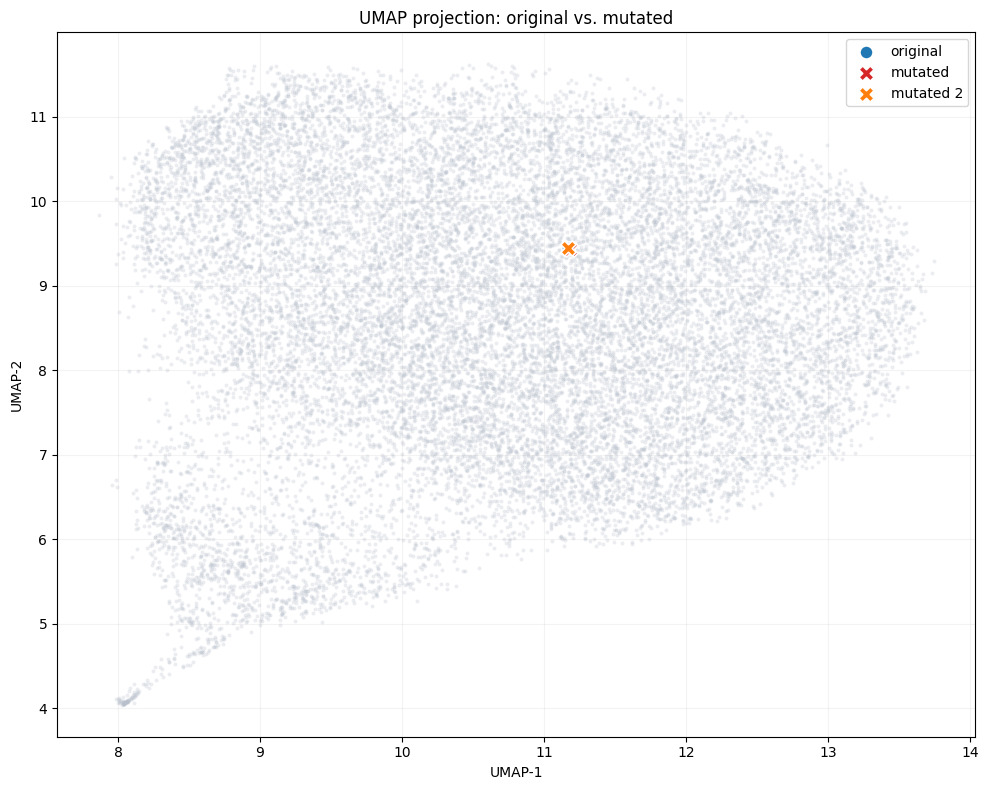

Original_embedding: [[-0.04565728 -0.48053825 -0.7006537  -0.199157   -0.11830658 -0.38090548
   0.20979232  0.14963491  0.21596216  1.428323    0.75453454  0.47782287
   0.25019732 -0.02509861 -0.25988308  0.6432538   0.66299415 -0.27574527
  -0.5407627  -1.2041435  -0.80942076  0.6446521  -1.1174715  -0.40127605
   0.08329742 -0.4105414  -0.29995045  0.6664998   0.26190087  0.27820885
   0.09645879 -0.5006805 ]]
Mutated_embedding: [[-0.05879081 -0.5476922  -0.529364   -0.30564296 -0.12544858 -0.38869044
   0.19881123 -0.12881732  0.31679514  1.3243572   0.7208381   0.3818613
   0.27274     0.02513535 -0.26532677  0.67086667  0.65131265 -0.3900367
  -0.535459   -1.1057594  -0.8142962   0.6273407  -1.0791113  -0.35718757
   0.11804129 -0.34524116 -0.3654311   0.46303418  0.16268982  0.37074864
   0.06762957 -0.5386248 ]]
Mutated_embedding_2: [[-0.04565728 -0.48053825 -0.7006537  -0.199157   -0.11830658 -0.38090548
   0.20979232  0.14963491  0.21596216  1.428323    0.75453454  0.4778228

In [23]:
import matplotlib.pyplot as plt
from mapelite.evaluator import EvaluatorMetrics

evaluator = EvaluatorMetrics.load_pretrained(EMBEDDING_MODEL_PATH)

def _convert_metrics_to_embedding(metrics_data):
    """Convert raw metric data to VAE embedding."""
    if not metrics_data or len(metrics_data) == 0:
        return None
    metrics_array = np.array(metrics_data)
    embedding = evaluator.measure_from_metrics(metrics_array)
    return np.asarray(embedding).reshape(1, -1)

original_embedding = _convert_metrics_to_embedding(embedding_data)
mutated_embedding = _convert_metrics_to_embedding(mutated_embedding_data)
mutated_embedding_2 = _convert_metrics_to_embedding(mutated_embedding_data_2)

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(
    umap_model.embedding_[:, 0],
    umap_model.embedding_[:, 1],
    s=8,
    c="#b8c0cc",
    alpha=0.28,
    linewidths=0,
    label="_embeddings background",
)

if original_embedding is not None:
    original_umap = umap_model.transform(original_embedding)
    ax.scatter(
        original_umap[:, 0],
        original_umap[:, 1],
        s=90,
        c="#1f77b4",
        edgecolors="white",
        linewidths=1.2,
        label="original",
        zorder=3,
    )

if mutated_embedding is not None:
    mutated_umap = umap_model.transform(mutated_embedding)
    ax.scatter(
        mutated_umap[:, 0],
        mutated_umap[:, 1],
        s=120,
        c="#d62728",
        marker="X",
        edgecolors="white",
        linewidths=1.2,
        label="mutated",
        zorder=4,
    )
    
if mutated_embedding_2 is not None:
    mutated_umap_2 = umap_model.transform(mutated_embedding_2)
    ax.scatter(
        mutated_umap_2[:, 0],
        mutated_umap_2[:, 1],
        s=120,
        c="#ff7f0e",
        marker="X",
        edgecolors="white",
        linewidths=1.2,
        label="mutated 2",
        zorder=4,
    )

ax.set_title("UMAP projection: original vs. mutated")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend(frameon=True)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

print("Original_embedding:", original_embedding)
print("Mutated_embedding:", mutated_embedding)
print("Mutated_embedding_2:", mutated_embedding_2)